# Lab 03. Minimizing Cost

선형회귀의 비용함수 최소화

## 목표

- `Lab 02_2`의 신경망 형식을 유지하면서 비용 최소화 과정 이해하기
- 여러 가중치에서 Cost(코스트, 비용)를 계산하고 그래프로 확인하기
- Gradient(그래디언트, 기울기)를 직접 계산하고 자동미분 결과와 비교하기
- Gradient Descent(그래디언트 디센트, 경사하강법)로 가중치 갱신하기
- 초기 가중치가 달라도 같은 최솟값으로 수렴하는 과정 확인하기


## 실습 단계

### 1. 라이브러리 불러오기
* 라이브러리<없다면> 설치 $ : python -m pip install matplotlib

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# 재현성: 난수 고정
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)


PyTorch 버전: 2.13.0+cu130


### 2. 학습 데이터 준비하기

입력과 실제값이 같은 데이터를 사용합니다.

$$
(1,1),\ (2,2),\ (3,3)
$$

이 데이터의 관계는 $y=x$이므로 최적 가중치는 $W=1$입니다.


In [3]:
# 학습 데이터: [데이터 수, 특성 수]
x_train = torch.tensor([[1.0], [2.0], [3.0]], dtype=torch.float32)
y_train = torch.tensor([[1.0], [2.0], [3.0]], dtype=torch.float32)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: torch.Size([3, 1])
y_train shape: torch.Size([3, 1])


### 3. 가설 단순화하기

`Lab 02_2`에서는 가중치 $W$와 편향 $b$를 함께 학습했습니다.

$$
\hat{y}=Wx+b
$$

이번 실습에서는 비용함수의 모양을 쉽게 확인하기 위해 편향을 잠시 제외합니다.

$$
\hat{y}=Wx
$$

이는 편향이 필요 없다는 뜻이 아니라, $W$의 이동만 관찰하기 위한 단순화입니다.


In [4]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Lab 02_2: 가중치·편향 학습
        # self.linear = nn.Linear(1, 1)

        # (변경) 편향 제외: H(x) = W*x
        self.linear = nn.Linear(1, 1, bias=False)

    def forward(self, x):
        # 순전파
        prediction = self.linear(x)
        return prediction


model = LinearRegressionModel()
print(model)


LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=False)
)


### 4. 가중치에 따른 비용 계산하기

MSE(엠에스이, 평균제곱오차)는 예측값과 실제값의 차이를 제곱한 뒤 평균합니다.

$$
cost(W)=\frac{1}{m}\sum_{i=1}^{m}(Wx^{(i)}-y^{(i)})^2
$$

- $W=0$ → 비용 약 $4.67$
- $W=1$ → 비용 $0$
- $W=2$ → 비용 약 $4.67$


In [5]:
loss_function = nn.MSELoss()


def calculate_cost(weight):
    # 후보 가중치
    weight_tensor = torch.tensor(weight, dtype=torch.float32)

    # 예측·비용
    prediction = weight_tensor * x_train
    cost = loss_function(prediction, y_train)
    return cost.item()


for weight in [0.0, 1.0, 2.0]:
    print(f"W: {weight:.1f} | cost: {calculate_cost(weight):.4f}")


W: 0.0 | cost: 4.6667
W: 1.0 | cost: 0.0000
W: 2.0 | cost: 4.6667


### 5. 비용함수 그래프 그리기

여러 가중치에서 비용을 계산하면 $W=1$이 최저점인 포물선이 나타납니다.

**The minimum cost occurs at $W=1$.**  
**최소 비용은 $W=1$에서 나타납니다.**


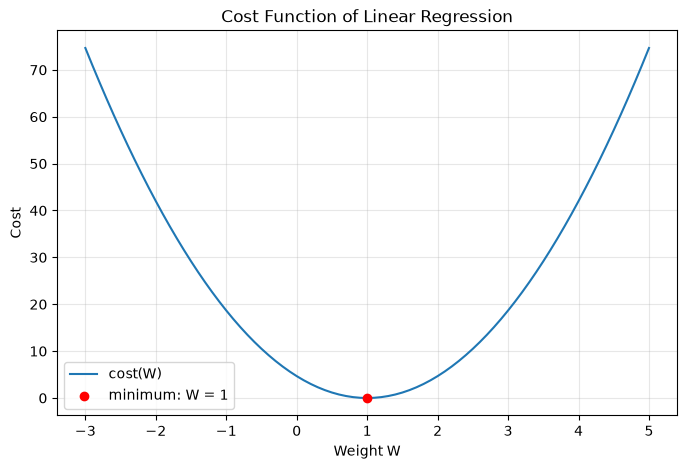

In [6]:
# 가중치 후보
weight_values = torch.linspace(-3.0, 5.0, steps=161)

# 비용 계산
cost_values = [calculate_cost(weight.item()) for weight in weight_values]

# 비용 곡선
plt.figure(figsize=(8, 5))
plt.plot(weight_values.numpy(), cost_values, label="cost(W)")
plt.scatter([1.0], [0.0], color="red", zorder=3, label="minimum: W = 1")
plt.xlabel("Weight W")
plt.ylabel("Cost")
plt.title("Cost Function of Linear Regression")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 6. 기울기 직접 계산하기

현재 데이터에서 비용함수는 다음과 같습니다.

$$
cost(W)=\frac{14}{3}(W-1)^2
$$

이를 미분하면 다음 기울기를 얻습니다.

$$
\frac{\partial cost}{\partial W}
=\frac{28}{3}(W-1)
$$

경사하강법은 현재 가중치에서 기울기에 학습률을 곱한 값을 뺍니다.

$$
W_{\text{new}}
=W_{\text{old}}-\alpha\frac{\partial cost}{\partial W}
$$


In [7]:
# 시작 가중치
weight = torch.tensor(5.0)
learning_rate = 0.1

# 직접 기울기
manual_gradient = 2 * ((weight * x_train - y_train) * x_train).mean()

# 직접 갱신
updated_weight = weight - learning_rate * manual_gradient

print("현재 W:", weight.item())
print("직접 계산한 기울기:", manual_gradient.item())
print("갱신된 W:", updated_weight.item())


현재 W: 5.0
직접 계산한 기울기: 37.33333206176758
갱신된 W: 1.2666666507720947


### 7. 자동미분 결과와 비교하기

PyTorch(파이토치)는 `backward()`를 실행하면 계산 과정을 따라 기울기를 자동으로 구합니다.

- 직접 계산: 미분식을 코드로 작성
- 자동미분: `loss.backward()` 실행
- 결과: 같은 기울기


In [8]:
# 자동미분용 가중치
weight_autograd = torch.tensor(5.0, requires_grad=True)

# 순전파·손실
prediction = weight_autograd * x_train
loss = loss_function(prediction, y_train)

# 자동미분
loss.backward()

print("직접 계산한 기울기:", manual_gradient.item())
print("자동미분 기울기:", weight_autograd.grad.item())
print(
    "두 기울기의 차이:",
    abs(manual_gradient.item() - weight_autograd.grad.item()),
)


직접 계산한 기울기: 37.33333206176758
자동미분 기울기: 37.333335876464844
두 기울기의 차이: 3.814697265625e-06


### 8. 최적화 도구로 비용 최소화하기

`Lab 02_2`의 학습 반복 구조를 그대로 사용합니다.

1. `model(x_train)` → 예측
2. `loss_function(...)` → 비용 계산
3. `zero_grad()` → 이전 기울기 초기화
4. `backward()` → 현재 기울기 계산
5. `step()` → 가중치 갱신

직접 작성한 갱신식은 `optimizer.step()`으로 바뀝니다.


In [9]:
# 모델 초기화
model = LinearRegressionModel()

with torch.no_grad():
    # 시작 가중치: 5
    model.linear.weight.fill_(5.0)

# Lab 02_2: 모델 전체 매개변수
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# (변경) 비용 곡선 확인용 학습률
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 20
weight_history = []
loss_history = []

for epoch in range(epochs + 1):
    # 순전파·비용
    prediction = model(x_train)
    loss = loss_function(prediction, y_train)

    # 초기화·역전파·갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 학습 기록
    current_weight = model.linear.weight.item()
    weight_history.append(current_weight)
    loss_history.append(loss.item())

    if epoch < 5 or epoch % 5 == 0:
        print(
            f"epoch: {epoch:2d} | "
            f"cost: {loss.item():.8f} | "
            f"W: {current_weight:.6f}"
        )


epoch:  0 | cost: 74.66666412 | W: 1.266666
epoch:  1 | cost: 0.33185121 | W: 1.017778
epoch:  2 | cost: 0.00147490 | W: 1.001185
epoch:  3 | cost: 0.00000656 | W: 1.000079
epoch:  4 | cost: 0.00000003 | W: 1.000005
epoch:  5 | cost: 0.00000000 | W: 1.000000
epoch: 10 | cost: 0.00000000 | W: 1.000000
epoch: 15 | cost: 0.00000000 | W: 1.000000
epoch: 20 | cost: 0.00000000 | W: 1.000000


### 9. 가중치 이동 과정 확인하기

오른쪽에서 시작한 $W=5$는 양의 기울기를 빼면서 왼쪽으로 이동합니다.  
학습이 진행될수록 $W$는 $1$에 가까워지고 비용은 $0$에 가까워집니다.


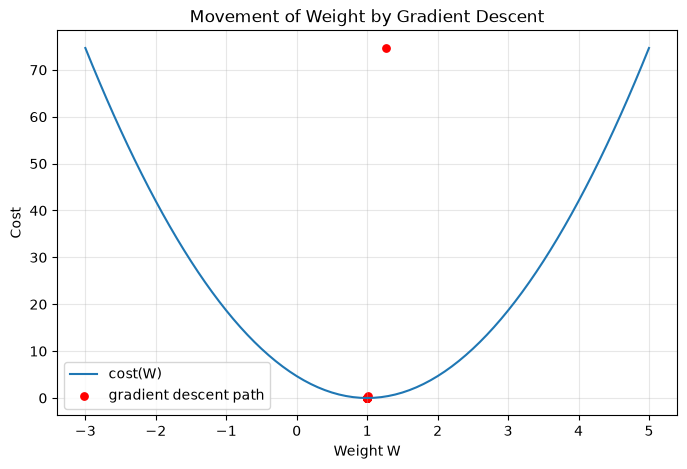

In [10]:
# 비용 곡선
plt.figure(figsize=(8, 5))
plt.plot(weight_values.numpy(), cost_values, label="cost(W)")

# 학습 경로
plt.scatter(
    weight_history,
    loss_history,
    color="red",
    s=28,
    label="gradient descent path",
)

plt.xlabel("Weight W")
plt.ylabel("Cost")
plt.title("Movement of Weight by Gradient Descent")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 10. 시작점이 달라도 수렴하는지 확인하기

선형회귀의 MSE 비용함수는 Convex Function(컨벡스 펑션, 볼록 함수)입니다.  
적절한 학습률에서는 시작점이 달라도 같은 전역 최솟값으로 이동합니다.


In [11]:
def train_from_start(start_weight, learning_rate=0.1, epochs=20):
    # 모델 생성
    test_model = LinearRegressionModel()

    # 시작 가중치
    with torch.no_grad():
        test_model.linear.weight.fill_(start_weight)

    # 최적화 도구
    test_optimizer = torch.optim.SGD(
        test_model.parameters(),
        lr=learning_rate,
    )

    # 학습
    for _ in range(epochs):
        prediction = test_model(x_train)
        loss = loss_function(prediction, y_train)

        test_optimizer.zero_grad()
        loss.backward()
        test_optimizer.step()

    return test_model.linear.weight.item(), loss.item()


for start_weight in [5.0, -3.0]:
    final_weight, final_cost = train_from_start(start_weight)
    print(
        f"시작 W: {start_weight:4.1f} | "
        f"최종 W: {final_weight:.6f} | "
        f"최종 cost: {final_cost:.10f}"
    )


시작 W:  5.0 | 최종 W: 1.000000 | 최종 cost: 0.0000000000
시작 W: -3.0 | 최종 W: 1.000000 | 최종 cost: 0.0000000000


### 11. 학습률의 영향 확인하기

Learning Rate(러닝 레이트, 학습률)는 한 번에 이동하는 크기입니다.

- 너무 작음 → 천천히 수렴
- 적절함 → 안정적으로 빠르게 수렴
- 너무 큼 → 최저점을 지나치며 발산 가능


In [12]:
learning_rates = [0.01, 0.1, 0.3]

for learning_rate in learning_rates:
    final_weight, final_cost = train_from_start(
        start_weight=5.0,
        learning_rate=learning_rate,
        epochs=20,
    )
    print(
        f"학습률: {learning_rate:.2f} | "
        f"최종 W: {final_weight:.6f} | "
        f"최종 cost: {final_cost:.6f}"
    )


학습률: 0.01 | 최종 W: 1.563655 | 최종 cost: 1.803589
학습률: 0.10 | 최종 W: 1.000000 | 최종 cost: 0.000000
학습률: 0.30 | 최종 W: 509931.500000 | 최종 cost: 374527361024.000000


## 확인 실습

입력 전압과 출력값의 관계가 $y=2x$인 센서 모델을 학습합니다.

- 시작 가중치: $W=-3$
- 학습률: $0.1$
- 반복 횟수: $20$
- 목표 가중치: $W\approx2$


In [13]:
sensor_x = torch.tensor([[1.0], [2.0], [3.0]], dtype=torch.float32)
sensor_y = torch.tensor([[2.0], [4.0], [6.0]], dtype=torch.float32)

# TODO 1: 모델 생성
sensor_model = LinearRegressionModel()

# TODO 2: 시작 가중치
with torch.no_grad():
    sensor_model.linear.weight.fill_(-3.0)

# TODO 3: 최적화 도구
sensor_optimizer = torch.optim.SGD(sensor_model.parameters(), lr=0.1)

# TODO 4: 학습
sensor_loss_history = []

for epoch in range(20):
    sensor_prediction = sensor_model(sensor_x)
    sensor_loss = loss_function(sensor_prediction, sensor_y)

    sensor_optimizer.zero_grad()
    sensor_loss.backward()
    sensor_optimizer.step()

    sensor_loss_history.append(sensor_loss.item())

print("학습된 W:", sensor_model.linear.weight.item())
print("최종 cost:", sensor_loss_history[-1])


학습된 W: 2.0
최종 cost: 0.0


## 실행 확인

아래 셀에서 오류가 없으면 `Lab 03`이 정상적으로 완료된 것입니다.


In [19]:
assert x_train.shape == torch.Size([3, 1])
assert y_train.shape == torch.Size([3, 1])
assert abs(calculate_cost(0.0) - 14 / 3) < 1e-5
assert calculate_cost(1.0) < 1e-8
assert abs(calculate_cost(2.0) - 14 / 3) < 1e-5
assert abs(manual_gradient.item() - weight_autograd.grad.item()) < 1e-5
assert abs(model.linear.weight.item() - 1.0) < 1e-4
assert loss_history[-1] < 1e-7
assert abs(sensor_model.linear.weight.item() - 2.0) < 1e-4
assert sensor_loss_history[-1] < 1e-7

print("Lab 03 실행 확인 완료")


Lab 03 실행 확인 완료


## 핵심 정리

- 학습 목표: 비용을 최소화하는 가중치 찾기
- 비용 곡선: $W=1$이 최저점인 포물선
- 기울기: 현재 위치에서 비용이 증가하는 방향과 크기
- 경사하강법: 기울기의 반대 방향으로 가중치 갱신
- 자동미분: `backward()`로 기울기 계산
- 가중치 갱신: `optimizer.step()`으로 실행
- 볼록 함수: 적절한 학습률에서 같은 전역 최솟값으로 수렴

